## Setup all variables from pkg_layers_doc. We will go one by one.

- also the convergence
- also the gateway term as a direct volume transport
- goal of this is to prove again, why this will not work because we need a sub-cell tendency.

In [1]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

(450, 90)
RAC2d (40500,)
(100,)


In [2]:
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [3]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

mymsk = np.full((ny,nx),np.nan)
mymsk[ind2d == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

ind = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

In [4]:
# ok we defined mymsk, now we need to define the indices in ind where these are selected
# load the JtermsT from the function (see previous configuration of layers)

# not sure if this will be the correct way to load it but we can check
# we will use the bins from the An run so that we have the same thing in both sections
# Paths for the bins in this run
filename = "layers2TH"
boundsT = rdmds(layers_path + filename)
binsTH_edges = boundsT.reshape(boundsT.shape[0])
binsTH_centers = (binsTH_edges[:-1] + binsTH_edges[1:])/2
nT = binsTH_edges.shape[0]-1
print(nT)

filename = "layers1SLT"
boundsS = rdmds(layers_path + filename)
binsSLT_edges = boundsS.reshape(boundsS.shape[0])
binsSLT_centers = (binsSLT_edges[:-1] + binsSLT_edges[1:])/2
nS = binsSLT_edges.shape[0]-1
print(nS)

binwidthT = binsTH_edges[1:] - binsTH_edges[:-1]
print(binwidthT.shape)
binwidthS = binsSLT_edges[1:] - binsSLT_edges[:-1]

binwidthT1 = (binwidthT[:-1] + binwidthT[1:])/2
binwidthS1 = (binwidthS[:-1] + binwidthS[1:])/2

dT,dS = np.meshgrid(binwidthT,binwidthS)
dT = dT.reshape(112,112,1)
dS = dS.reshape(112,112,1)

binmidT = ((boundsT[:-1] + boundsT[1:])/2).reshape(nT)
binmidS = ((boundsS[:-1] + boundsS[1:])/2).reshape(nT)

binmidTp = boundsT[1:-1]
binmidSp = boundsS[1:-1]

Tbin,Sbin = np.meshgrid(binsTH_edges,binsSLT_edges)
Tbincent,Sbincent = np.meshgrid(binsTH_centers,binsSLT_centers)
Tbin2,Sbin2 = np.meshgrid(binmidTp,binmidSp)

112
112
(112,)


# Eq. 2 and Eq. 3 in pkg_layers_doc are the G terms
### Load the G terms from online diagnostics output from layers

In [5]:
# we need to also create the theta and salt bins for this area
tsstr = np.array(["0000000003","0000000004"])
t2 = int(tsstr[1]) # for the offline version

In [6]:
ffac=1e-6
G_T=np.array([])
metaT=parsemeta(layers_path + "diags/LAYERS/layers_3d_Ttend." + tsstr[1] + ".meta")
nFldsT = metaT["fldList"]
print(len(nFldsT))
setTtend=nFldsT.copy()
fldsIwant = np.array(['LaTh2TH','LaTz2TH'])

# check for the correct diagnostics
metaT['fldList']   # 13, 14, 15, 16, 19, 22
b = metaT['fldList']
ifldT = np.array([1,2])    # surf, hDiff, vDiff, hADV, vADV, total tend
# print(np.array(b)[ifldT])  # for G_T

# remake the following to look for the existing terms and see if we can recreate
# ['LaTs2TH' 'LaTh2TH' 'LaTz2TH' 'LTha2TH' 'LTza2TH' 'LTto2TH']
ifldT = np.array([0,1,2,7,8,11])
print(np.array(b)[ifldT])  # for G_T


# we will just do the exact same thing for all the terms
metaS=parsemeta(layers_path + "diags/LAYERS/layers_3d_Stend." + tsstr[1] + ".meta")
nFldsS = metaS["fldList"]
print(len(nFldsT))
setStend=nFldsS.copy()

# check for the correct diagnostics
metaS['fldList']   # 13, 14, 15, 16, 19, 22
b = metaS['fldList']
# ['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']
ifldS = np.array([12,13,14,19,20,23])

# print(b[12,13,14,19,20,23])
print(np.array(b)[ifldS])  # for G_S

24
['LaTs2TH' 'LaTh2TH' 'LaTz2TH' 'LTha2TH' 'LTza2TH' 'LTto2TH']
24
['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']


In [7]:
# create the iwet for a specific, singular column with two cells.
iy,ix = 150,19

In [8]:
# create iwet from a mask at these points
mymsk = np.full((ny,nx),np.nan)
mymsk[iy,ix] = 1
mymsk_1d = mymsk.reshape(orig_shape, order='C')
mymsk_1dtile = np.tile(mymsk_1d[np.newaxis,:],(nT-1,1))
# mymsk3d.shape
# hf2dtile.shape
iwet_mine = np.where(~np.isnan(mymsk_1d))
iwet_mine[0].shape
iwet_mine = iwet_mine[0]   # this is already the 1D array of wetpoints to use, we can add these below by indexing

In [9]:
iwet_mine

array([13519])

In [10]:
hf0 = mygrid['hFacC'][0]
landmsk = np.full((ny,nx),np.nan)
landmsk[np.isnan(hf0 )] = 1

(150.0, 300.0)

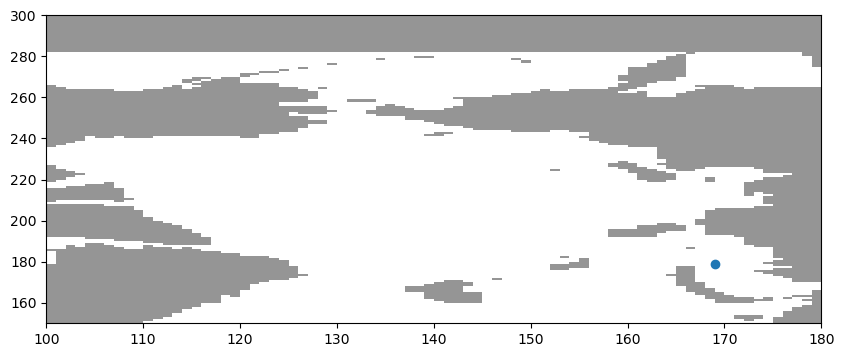

In [11]:
# show in the whole Arctic where this is

pt_tracer = np.full((ny,nx),np.nan)
pt_tracer[iy,ix] = 1
pt_tracer = get_aste_tracer(pt_tracer,nfx,nfy)[0]


dep_aste = mygrid['Depth']
# plt.pcolormesh(get_aste_tracer(dep_aste,nfx,nfy)[0])
plt.pcolormesh(get_aste_tracer(landmsk,nfx,nfy)[0],cmap='Greys', vmin=-2,vmax=4)
# plt.pcolormesh(pt_tracer,cmap='rainbow', vmin=-2,vmax=4)
plt.scatter(169,179)
plt.xlim(100,180)
plt.ylim(150,300)



In [12]:
np.where(pt_tracer ==1)

(array([169]), array([179]))

In [13]:
np.where(pt_faces.f3[0])

NameError: name 'pt_faces' is not defined

In [ ]:
dep_faces = get_aste_faces(dep_aste,nfx,nfy)
pt_tracer = np.full((ny,nx),np.nan)
pt_tracer[iy,ix] = 1
pt_faces = get_aste_faces(pt_tracer,nfx,nfy)
land_faces = get_aste_faces(landmsk,nfx,nfy)

fig = plt.figure(figsize = (5,5))
ax = plt.subplot(111)
ax.pcolormesh(dep_faces.f3[0])
ax.pcolormesh(land_faces.f3[0],cmap="Greys",vmin=-2,vmax=4)
ax.pcolormesh(pt_faces.f3[0],cmap="rainbow_r")

# ax = plt.subplot(122)
# # plt.pcolormesh(get_aste_tracer(dep_aste,nfx,nfy)[0])
# ax.pcolormesh(get_aste_tracer(landmsk,nfx,nfy)[0],cmap='Greys', vmin=-2,vmax=4)
# # plt.pcolormesh(pt_tracer,cmap='rainbow', vmin=-2,vmax=4)
# ax.scatter(169,179)
# ax.set_xlim(100,180)
# ax.set_ylim(150,270)


In [14]:
print(THETA[:3,iy,ix])
print(SALT[:3,iy,ix])

NameError: name 'THETA' is not defined

In [239]:
print(binmidT[:2])
print(binmidS[83:85])

[-2.60000002 -2.20000005]
[32.875 33.125]


(-5.0, 0.0)

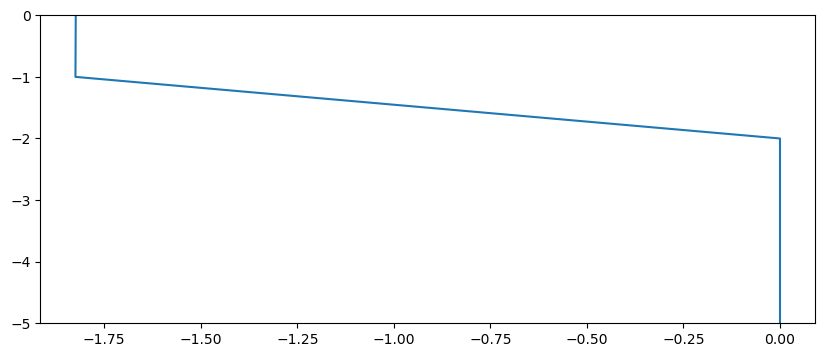

In [233]:
fig = plt.figure()

myz = np.arange(0,-50,-1)
ax = plt.subplot(111)
ax.plot(THETA[:,iy,ix],myz)
ax.set_ylim(-5,0)

In [16]:
# load G_T and G_S for this specific point online
# we did not mask this or the other one which is why they are the same
# try to make sure we maskt this here.

name = "BarentsS"
G_T = {}
G_T[name] = {}
ts = tsstr[1]
    
# now loop through
G_T[name][ts] = {}
for i in range(len(ifldT)-1, -1, -1):
    tmp = read_float64_skip(layers_path + "diags/LAYERS/layers_3d_Ttend." + tsstr[-1] + ".data", nx*ny*(nT-1),ifldT[i])
    tmp = np.reshape(tmp,(nT-1,nx*ny))
    tmp = tmp * (rac2dtile * hf2dtile) #* ffac

    if i == ifldT.shape[0]-1:
        # if LTto2TH, do not remove from residual
        residT = tmp
    else:
        # else if vADV, hADV, vDiff, hDiff, surface, remove from residual
        residT = residT-tmp
    
    # just do the Barents Sea for this one
    a = np.nansum(tmp[:,iwet_mine],axis=1)
    G_T[name][ts][setTtend[ifldT[i]]] = a

# residT was wrong here so we can just ignore

# let's try to verify with G_T first and then start with G_S
# make the G_T term
# we did not mask this or the other one which is why they are the same
# try to make sure we maskt this here.
metaS=parsemeta(layers_path + "diags/LAYERS/layers_3d_Stend." + "0000000003" + ".meta")
nFldsS = metaS["fldList"]
print(len(nFldsT))
setTtend=nFldsT.copy()
# check for the correct diagnostics
metaS['fldList']   # 13, 14, 15, 16, 19, 22
b = metaS['fldList']
# ['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']
ifldS = np.array([12,13,14,19,20,23])

# print(b[12,13,14,19,20,23])
print(np.array(b)[ifldS])  # for G_S

# make the G_T term
G_S = {}
G_S["BarentsS"] = {}
    
# now loop through
G_S["BarentsS"][ts] = {}
for i in range(len(ifldS)-1, -1, -1):
    tmp = read_float64_skip(layers_path + "diags/LAYERS/layers_3d_Stend." + tsstr[-1] + ".data", nx*ny*(nS-1),ifldS[i])
    tmp = np.reshape(tmp,(nS-1,nx*ny))

    # here we will want to multiply by the mask for the Barents Sea
    tmp = tmp * mymsk_1dtile * (rac2dtile * hf2dtile) #* ffac

    if i == ifldS.shape[0]-1:
        # if LTto2TH, do not remove from residual
        residS = tmp
    else:
        # else if vADV, hADV, vDiff, hDiff, surface, remove from residual
        residS = residT-tmp
    
    # just do the Barents Sea for this one
    a = np.nansum(tmp[:,iwet_mine],axis=1)
    G_S["BarentsS"][ts][setTtend[ifldS[i]]] = a


24
['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']


In [17]:
# plt.pcolormesh(mymsk)

In [15]:
# load the G_S and G_T for offline for the same column in the package
from create_aste90_layers import create_layers_totalTHETA,create_layers_totalSALT

# load the same terms for this mymsk of 1 pt x 2 nz

t2 = int(tsstr[1])
# 'diags/state_3d_set1'
# read theta and salt averages from the t2 timestep (average)
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz,ny,nx)
SALT = SALT.reshape(nz,ny,nx)

# load these terms 
dt = 1800

MsumT,dF_Tnew = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=False,debug=True)
MsumS,dF_Snew = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=False,debug=True)
# these have advh, advr, dfh, dfr, surf, kpp, tend and have not been normalized

In [18]:
print(G_T['BarentsS'][ts].keys())
print(G_S['BarentsS'][ts].keys())

# the order of these is tend, advr, advh, dfr, dfh, surf

new_order = ['LTha2TH', 'LTza2TH', 'LaTh2TH', 'LaTz2TH', 'LaTs2TH', 'LTto2TH']
dT = G_T['BarentsS'][ts]
G_T['BarentsS'][ts] = {k: dT[k] for k in new_order}


new_order = ['LTha1SLT', 'LTza1SLT', 'LaTh1SLT', 'LaTz1SLT', 'LaTs1SLT', 'LTto1SLT']
dS = G_S['BarentsS'][ts]
G_S['BarentsS'][ts] = {k: dS[k] for k in new_order}

dict_keys(['LTto2TH', 'LTza2TH', 'LTha2TH', 'LaTz2TH', 'LaTh2TH', 'LaTs2TH'])
dict_keys(['LTto1SLT', 'LTza1SLT', 'LTha1SLT', 'LaTz1SLT', 'LaTh1SLT', 'LaTs1SLT'])


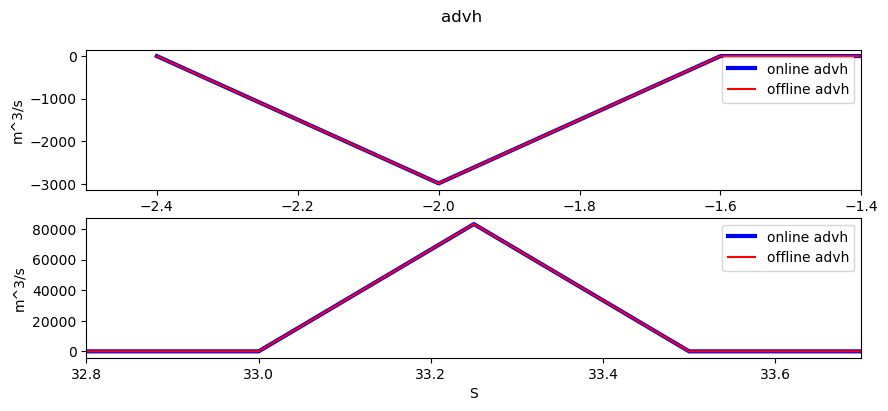

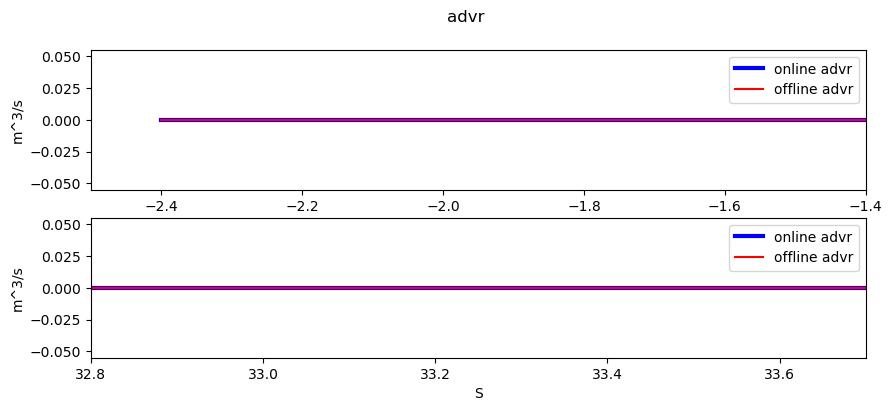

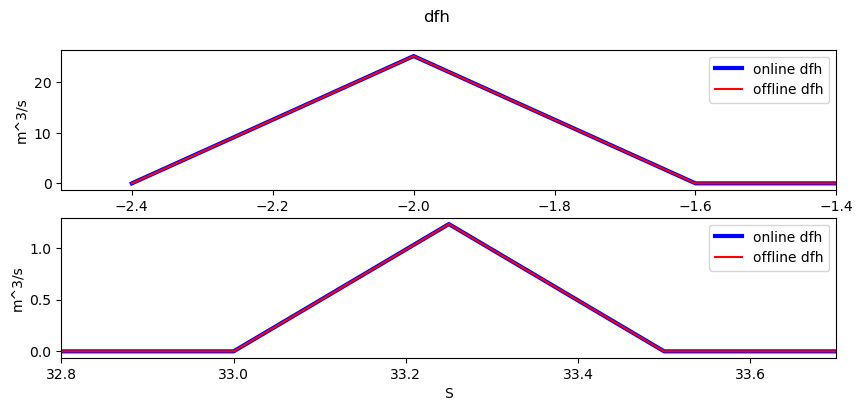

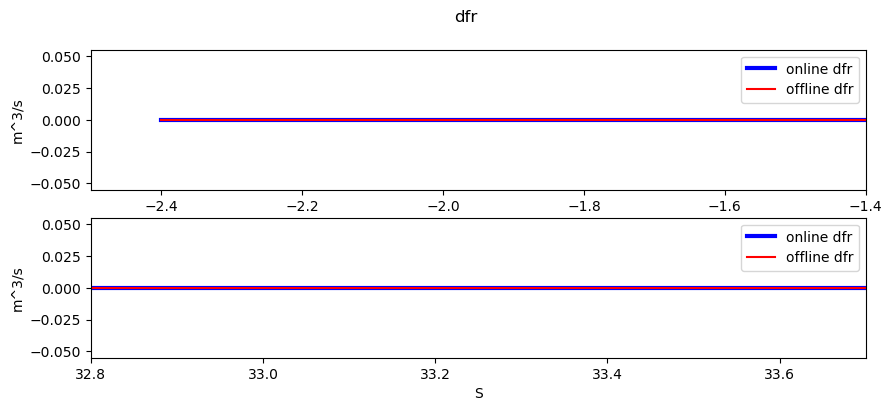

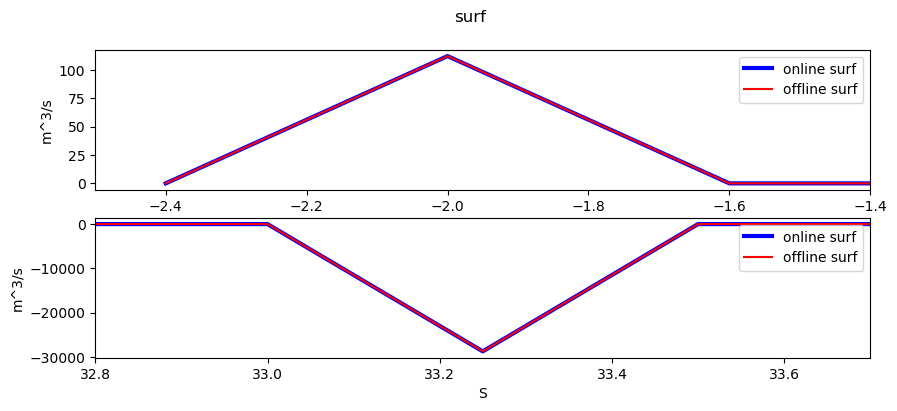

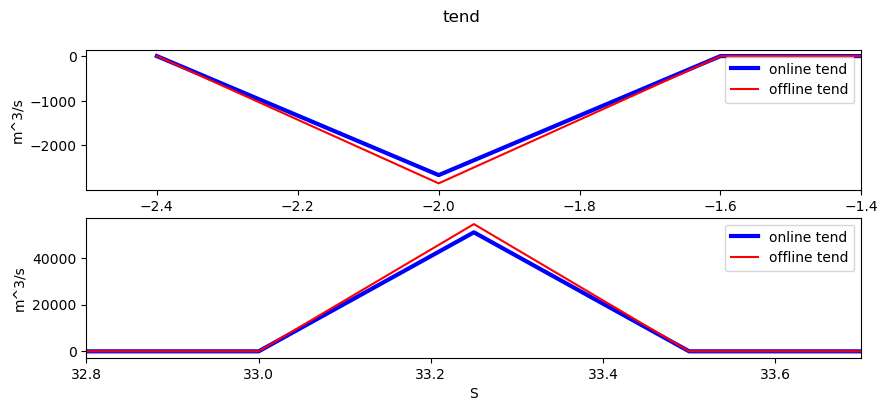

In [19]:
# plot these against the online terms

# make some kind of function to choose which term to use and make two plots


def plot_G(term,boundsS,boundsT,order):
    # just make term the index we want
    keyGT = list(G_T["BarentsS"][ts].keys())[term]
    keyGS = list(G_S["BarentsS"][ts].keys())[term]

    if term ==5:
        termoff = 6
    else:
        termoff = term

    fig = plt.figure()

    ax = plt.subplot(211)
    ax.plot(boundsT.flatten()[1:-1],G_T["BarentsS"][ts][keyGT],c="blue",linewidth=3,label="online " + order[term])
    ax.plot(boundsT.flatten()[1:-1],dF_Tnew[termoff]/binwidthT1,c="red",label="offline " + order[term])
    ax.set_ylabel("m^3/s")
    ax.set_xlabel("T")
    ax.legend(loc="best")
    ax.set_xlim(-2.5,-1.4)

    ax = plt.subplot(212)
    ax.plot(boundsS.flatten()[1:-1],G_S["BarentsS"][ts][keyGS],c="blue",linewidth=3,label="online " + order[term])
    ax.plot(boundsS.flatten()[1:-1],dF_Snew[termoff]/binwidthS1,c="red",label="offline " + order[term])
    ax.set_ylabel("m^3/s")
    ax.set_xlabel("S")
    ax.legend(loc="best")
    ax.set_xlim(32.8,33.7)

    plt.suptitle(order[term])


for i in range(6):
    plot_G(i,boundsS,boundsT,np.array(['advh', 'advr', 'dfh', 'dfr', 'surf', 'tend']))

In [22]:
dF_Tnew[0]

array([    0.        , -1195.11858297,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ,
      

In [76]:
# why is the total tendency different?
# (dF_Snew[-2])

In [77]:
sum = 0
for key in list(G_S["BarentsS"][ts].keys())[:-1]:
    #print(G_S["BarentsS"][ts][key])
    sum += np.nansum(G_S["BarentsS"][ts][key])
    print(np.nansum(sum))
print()
print(np.nansum(G_S["BarentsS"][ts]["LTto1SLT"]))  # this is difference potentially due to hFacC online total tend.

83310.54469007913
83310.54469007913
83311.77706537691
83311.77706537691
54527.01425854239

50996.60635402925


In [78]:
sum = 0
for key in range(6):
    #print(G_S["BarentsS"][ts][key])
    sum += dF_Snew[key]/binwidthS1
    print(np.nansum(sum))

83310.54469007917
83310.54469007917
83311.77706537695
83311.77706537695
54527.01425854243
54527.01425854243


In [85]:
# print specifically the residual for this

keys = list(G_S["BarentsS"][ts].keys())[:-1]
cum_G = 0.0
cum_dF = 0.0

for k, key in enumerate(keys):
    term_G  = np.nansum(G_S["BarentsS"][ts][key])
    term_dF = np.nansum(dF_Snew[k] / binwidthS1)

    cum_G  += term_G
    cum_dF += term_dF

    print(f"{key}: term_resid={term_G - term_dF}  m^3/s")

print()
tend_dF = np.nansum(dF_Snew[-1] / binwidthS1)
tend_on = np.nansum(G_S["BarentsS"][ts]["LTto1SLT"])
key = "LTto1SLT"
print(f"{key}: term_resid={tend_on - tend_dF} m^3/s")


LTha1SLT: term_resid=-4.3655745685100555e-11  m^3/s
LTza1SLT: term_resid=0.0  m^3/s
LaTh1SLT: term_resid=2.220446049250313e-16  m^3/s
LaTz1SLT: term_resid=0.0  m^3/s
LaTs1SLT: term_resid=0.0  m^3/s

LTto1SLT: term_resid=-3530.4079057583585 m^3/s


In [80]:
G_S["BarentsS"][ts].keys()

dict_keys(['LTha1SLT', 'LTza1SLT', 'LaTh1SLT', 'LaTz1SLT', 'LaTs1SLT', 'LTto1SLT'])

In [81]:
sum = 0
for key in list(G_T["BarentsS"][ts].keys())[:-1]:
    #print(G_S["BarentsS"][ts][key])
    sum += np.nansum(G_T["BarentsS"][ts][key])
    print(np.nansum(sum))
print()
print(np.nansum(G_T["BarentsS"][ts]["LTto2TH"]))

-2987.796457422174
-2987.796457422174
-2962.600222794279
-2962.600222794279
-2850.460661199092

-2665.9046390584203


In [82]:
sum = 0
for key in range(6):
    #print(G_S["BarentsS"][ts][key])
    sum += dF_Tnew[key]/binwidthT1
    print(np.nansum(sum))

-2987.79619029238
-2987.79619029238
-2962.599957917203
-2962.599957917203
-2850.4604063480733
-2850.4604063480733


In [86]:
# do the same print statement for this one


# print specifically the residual for this

keys = list(G_T["BarentsS"][ts].keys())[:-1]
cum_G = 0.0
cum_dF = 0.0

for k, key in enumerate(keys):
    term_G  = np.nansum(G_T["BarentsS"][ts][key])
    term_dF = np.nansum(dF_Tnew[k] / binwidthT1)

    cum_G  += term_G
    cum_dF += term_dF

    print(f"{key}: term_resid={term_G - term_dF}  m^3/s")

print()
tend_dF = np.nansum(dF_Tnew[-1] / binwidthS1)
tend_on = np.nansum(G_T["BarentsS"][ts]["LTto2TH"])
key = "LTto2TH"
print(f"{key}: term_resid={tend_on - tend_dF} m^3/s")


LTha2TH: term_resid=-0.00026712979433796136  m^3/s
LTza2TH: term_resid=0.0  m^3/s
LaTh2TH: term_resid=2.252718708461998e-06  m^3/s
LaTz2TH: term_resid=0.0  m^3/s
LaTs2TH: term_resid=1.0026057182699333e-05  m^3/s

LTto2TH: term_resid=-1525.720374570402 m^3/s


In [60]:
# binmidT

In [95]:
# # so plotting in this way is fine. we replicated layers, but the tend online is not the same as tend offline.
G_T_dfh = dF_Tnew[2]/binwidthT1   # m^3/s
G_T_dfh[:5]  # this is the contribution to salinity (Jy)

# # we're still not sure why these are different but we'll move on and write it again.

array([ 0.        , 25.19623238,  0.        ,  0.        ,  0.        ])

In [96]:
boundsS.flatten().shape  # rename to center S

(113,)

In [97]:
binmidS.shape            # should rename to boundsS - from here can find the midpoints, or skip to boundsS[1:-1]

(112,)

In [98]:
boundsS.flatten()[1:-1].shape  # these are the midpoints of binmidS, rename to center S

(111,)

In [99]:
binmidS[84:86]     # these are the bounds, need to rename


array([33.125, 33.375])

In [100]:
binmidS[84:86]     # these are the bounds, need to rename
binwidthS1[84:88]  # bin widths that we use to normalize (difference of binmid bounds)
boundsS.flatten()[1:-1] # boundsS are the centers (113 values in data.layers)

array([ 1.  ,  2.  ,  3.  ,  4.  ,  5.  ,  6.  ,  7.  ,  8.  ,  9.  ,
       10.  , 11.  , 12.  , 13.  , 14.  , 15.  , 16.  , 16.25, 16.5 ,
       16.75, 17.  , 17.25, 17.5 , 17.75, 18.  , 18.25, 18.5 , 18.75,
       19.  , 19.25, 19.5 , 19.75, 20.  , 20.25, 20.5 , 20.75, 21.  ,
       21.25, 21.5 , 21.75, 22.  , 22.25, 22.5 , 22.75, 23.  , 23.25,
       23.5 , 23.75, 24.  , 24.25, 24.5 , 24.75, 25.  , 25.25, 25.5 ,
       25.75, 26.  , 26.25, 26.5 , 26.75, 27.  , 27.25, 27.5 , 27.75,
       28.  , 28.25, 28.5 , 28.75, 29.  , 29.25, 29.5 , 29.75, 30.  ,
       30.25, 30.5 , 30.75, 31.  , 31.25, 31.5 , 31.75, 32.  , 32.25,
       32.5 , 32.75, 33.  , 33.25, 33.5 , 33.75, 34.  , 34.25, 34.5 ,
       34.75, 35.  , 35.25, 35.5 , 35.75, 36.  , 36.25, 36.5 , 36.75,
       37.  , 37.25, 37.5 , 37.75, 38.  , 38.25, 38.5 , 38.75, 39.  ,
       39.25, 39.5 , 39.75])

In [101]:
SALT[:5,iy,ix] 

array([33.32093048, 33.33365631,  0.        ,  0.        ,  0.        ])

In [79]:
nTm1 = nT-1
nSm1 = nS-1

In [102]:
# we can make an example array for each (probably same as below)
# but An wants us to distribute things as per G_T (ie per point)
# it would seem to me this is the same result as binning per-item

In [103]:
# J_DFh = np.zeros((nTm1,nSm1))  # derivative of G_T by dS
# # think of this as piling up on the left axis

# # this should be more methodical than just ad-hoc binning

# # G_T_dfh

# for iT in range(nTm1):
#     if G_T_dfh[iT] != 0:
#         for iS in range(nSm1):
#             if 

## do the same with the TS diagrams. Load the J terms online and plot them side by side with the J terms offline.

In [104]:
# the overall tend here is different for both. and not sure why. Let's plot an example convergence of T S diagrams from layers
# load the ifldT terms we need from the THETA field
# we are copying from Jy terms

# setTS_Ttend = ['LaTs_TS', 'LaTh_TS', 'LaTz_TS', 'LTha_TS', 'LTza_TS', 'LTto_TS']

# check these from the miniaste if same order
setTS_Ttend=parsemeta(dirlayers + "layers_TSjoint_Ttend_set1.0000000003.meta")["fldList"]
setTS_Ttend

setTS_Stend=parsemeta(dirlayers + "layers_TSjoint_Stend_set1.0000000003.meta")["fldList"]
setTS_Stend

['LaSs_TS', 'LaSh_TS', 'LaSz_TS', 'LSha_TS', 'LSza_TS', 'LSto_TS']

In [105]:
# do the Jy term
# DO NOT RUN IF HAS ALREADY BEEN CALCULATED
# JUST FOR SET1 HERE - NOT FOR SET 2
# 287 - should be indexing nt, ns, wetpoints
# T, S, wetpoints
Jy = {}
nbasin = "BarentsS"
# set each basin to its own dictionary
Jy[nbasin] = {}

rac = mygrid['RAC']
hf1 = hf1.reshape(ny,nx)
small = rac2d * hf2d

# loop through the existing timesteps
for t in tsstr[1:]:
    print(t)
    Jy[nbasin][t] = {}
    Jy[nbasin][t]['G_T'] = {}
    
    # now loop through the terms and add these to the dictionary
    for i in range(len(setTS_Ttend)-1, -1, -1):
        print(i)
        # read the file and apply masking
        filename = dirlayers + f"layers_TSjoint_Ttend_set1.{t}.data"  # check this with new layers dir
        tmp = read_float64_skip(filename, LwetC2d*(nS-1)*(nT-1),i)
        tmp = np.reshape(tmp,(nT-1,nS-1,LwetC2d))
        tmp = tmp * np.tile(small[np.newaxis,np.newaxis,:], (nT - 1, nS - 1,1)) * ffac
    
        # if at end of loop
        if i == len(setTS_Ttend)-1:
            f = (np.nansum(tmp, axis=2))
            f = np.nansum(f * binwidthS1)
    
        # double check the names in the listed file
        if i == len(setTS_Ttend)-1:
            # do not remove from the residual - this is the total tendency
            residT = tmp
        elif i in {0,1,2,3,4}:
            # LaTs_TS LaTh_TS LaTz_TS LTha_TS LTza_TS (LTBh_TS)
            # surface forcing, hDiff, vDiff, hADV, vADV, hADV bolus
            residT -= tmp
    
        tmp1 = np.nansum(tmp[:,:,iwet_mine],axis=2)   # SUM OVER WET POINTS - should be of shape nS-1, nT-1
        # TEST:
        # tmp1 = tmp1.T
        tmp2 = np.nansum(tmp1 * binwidthS1,axis=1)              # SUM OVER S - should be of shape nT-1
        Jy[nbasin][t][setTS_Ttend[i]] = tmp1
        Jy[nbasin][t]['G_T'][setTS_Ttend[i]] = tmp2
        del tmp
        del tmp1
        del tmp2


    myresid = np.nansum(residT[:,:,iwet_mine],axis=2)    # SUM OVER WET POINTS - should be of shape nS-1, nT-1
    # myresid = myresid.T
    Jy[nbasin][t]["residT"] = myresid
    Jy[nbasin][t]["G_T"]["residT"] = np.nansum(Jy[nbasin][t]["residT"] * binwidthS1,axis=1)   #SUM OVER S - should be of shape nT-1

    print()
# set units and labels
Jy["unit"] = "m/s/psu"

# # Define your filename
filename = "Jy_miniaste_single_pt.npz"
matpath = "/scratch2/mmurakami/aste_90x150x60/"
matpath += "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"

# # Save the dictionary
np.savez(matpath + filename, **Jy)

0000000004
5
4
3
2
1
0



In [106]:
# I think we need to redefine J with a single cell or a very small mask (maybe one cell)
# DO NOT RUN IF HAS ALREADY BEEN CALCULATED
Jx = {}
Jx[nbasin] = {}

rac = mygrid['RAC']
hf1 = hf1.reshape(ny,nx)

# loop through the existing timesteps
for t in tsstr[1:]:
    print(t)
    Jx[nbasin][t] = {}
    Jx[nbasin][t]['G_S'] = {}

    # loop through the diagnostics
    for i in range(len(setTS_Stend)-1, -1, -1):
        filename = dirlayers + f"layers_TSjoint_Stend_set1.{t}.data"
        tmp = read_float64_skip(filename, LwetC2d*(nS-1)*(nT-1),i)
        tmp = np.reshape(tmp,(nT-1,nS-1,LwetC2d))
        print(tmp.shape)
    
        small = rac2d * hf2d
        tmp = tmp * np.tile(small[np.newaxis,np.newaxis,:], (nT - 1, nS - 1,1)) * ffac
    
        if i == len(setTS_Stend)-1:
            # LSto_TS - total tendency
            residS = tmp
        elif i in {0,1,2,3,4}:
            # LaSs_TS LaSh_TS LaSz_TS LSha_TS LSza_TS LSBh_TS
            # surface, hdiff, vdiff, hADV, vADV, hADV bolus
            residS -= tmp
    
        # use stri_wet, strb is names of basins
        tmp1 = np.nansum(tmp[:,:,iwet_mine],axis=2)   # should be of shape nS-1, nT-1
        # TEST
        # tmp1 = tmp1.T
        thisbinwidthT1 = np.tile(binwidthT1[:,np.newaxis],(1, nS - 1))
        tmp2 = np.nansum(tmp1 * thisbinwidthT1, axis=1)                 # second dim is T because this is S tend
        print(setTS_Stend[i])
        Jx[nbasin][t][setTS_Stend[i]] = tmp1
        Jx[nbasin][t]['G_S'][setTS_Stend[i]] = tmp2
        del tmp
        del tmp1
        del tmp2

    tmp1 = np.nansum(residS[:,:,iwet_mine],axis=2)    # sum over geo space
    mytileT1 = np.tile(binwidthT1[np.newaxis,:],(nS-1,1))  # nS-1 x nT-1
    tmp2 = np.nansum(tmp1 * mytileT1, axis=0)     # sum over T ( dimension 0)
    Jx[nbasin][t]["residS"] = tmp1    # should be of shape nS-1, nT-1
    Jx[nbasin][t]["G_S"]["residS"] = tmp2 #should be of shape nT-1

# set units and labels
Jx["descr"] = "m/s/degC"

# # Define your filename
filename = "Jx_miniaste_single_pt.npz"
matpath = "/scratch2/mmurakami/aste_90x150x60/"
matpath += "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"

# # Save the dictionary
np.savez(matpath + filename, **Jx)

0000000004
(111, 111, 40500)
LSto_TS
(111, 111, 40500)
LSza_TS
(111, 111, 40500)
LSha_TS
(111, 111, 40500)
LaSz_TS
(111, 111, 40500)
LaSh_TS
(111, 111, 40500)
LaSs_TS


In [107]:
# create the same Jy offline as done before

dt = 1800
termsT3D = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=True)
termsS3D = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=True)


In [108]:
# termsT3D
print(iy,ix)

150 19


In [109]:
# termsT3D.keys()

In [110]:
def bin_3d_term_to_TS(term3d, THETA, SALT, mymsk3d, binmidT, binmidS, binwidthT1, binwidthS1):
    nT = len(binmidT)
    nS = len(binmidS)

    dF_TS = np.zeros((nT-1, nS-1), dtype=float)
    L_TS  = np.zeros((nT-1, nS-1), dtype=int)

    # Flatten
    T_flat = np.ravel(THETA * mymsk3d, order="F")
    S_flat = np.ravel(SALT  * mymsk3d, order="F")
    X_flat = np.ravel(term3d * mymsk3d, order="F")

    # Bin indices
    iT = np.searchsorted(binmidT, T_flat, side="right") - 1
    iS = np.searchsorted(binmidS, S_flat, side="right") - 1

    # Valid points
    ok = (iT >= 0) & (iT < nT-1) & (iS >= 0) & (iS < nS-1) & np.isfinite(X_flat)
    iT = iT[ok]
    iS = iS[ok]
    vals = X_flat[ok]

    # Accumulate
    np.add.at(dF_TS, (iT, iS), vals)
    np.add.at(L_TS,  (iT, iS), 1)

    # Normalize by both bin widths
    dA = binwidthT1[:, None] * binwidthS1[None, :]  # An suggests doing this separately in future
                                                    # first division in dT or dS gets you G_T or G_S
                                                    # second division by dS or dT gets you the J component of J_S or J_T
    G_TS = dF_TS / dA                               # should not be called G_TS here!

    return G_TS, dF_TS, L_TS

termsT_TS = {}
mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))
for k, arr3d in termsT3D.items():
    termsT_TS[k], _, _ = bin_3d_term_to_TS(
        arr3d, THETA, SALT, mymsk3d,
        binmidT, binmidS, binwidthT1, binwidthS1
    )

termsS_TS = {}
for k, arr3d in termsS3D.items():
    termsS_TS[k], _, _ = bin_3d_term_to_TS(
        arr3d, THETA, SALT, mymsk3d,
        binmidT, binmidS, binwidthT1, binwidthS1
    )

In [111]:
# iT = 1 , iS = 84    

In [112]:
for key in list(Jy[nbasin][t].keys())[1:]:
    print(key,np.nansum(Jy[nbasin][t][key]),"Sv/PSU")

LTto_TS -0.01066361855623368 Sv/PSU
LTza_TS 0.0 Sv/PSU
LTha_TS -0.011951185829688696 Sv/PSU
LaTz_TS 0.0 Sv/PSU
LaTh_TS 0.00010078493851158117 Sv/PSU
LaTs_TS 0.00044855824638074816 Sv/PSU
residT 0.000738224088562686 Sv/PSU


In [113]:
for key in list(termsT_TS.keys()):
    print(key,np.nansum(termsT_TS[key])*1e-6,"Sv/PSU")

ADVh -0.011951184761169518 Sv/PSU
ADVr 0.0 Sv/PSU
DFhT 0.00010078492950070633 Sv/PSU
DFrT 0.0 Sv/PSU
surf 0.00044855820627651946 Sv/PSU
KPP 0.0 Sv/PSU
tend -0.011401841625476103 Sv/PSU


In [116]:
print("Jy term or dG_T/dS") 

resid_ADVh = np.nansum(termsT_TS['ADVh'])*1e-6 - np.nansum(Jy[nbasin][t]['LTha_TS'])
print("resid_ADVh (horizontal advection residual):", resid_ADVh, "Sv/PSU")

resid_DFh = np.nansum(termsT_TS['DFhT'])*1e-6 - np.nansum(Jy[nbasin][t]['LaTh_TS'])
print("resid_DFh (horizontal diffusion residual):", resid_DFh, "Sv/PSU")

resid_surf = np.nansum(termsT_TS['surf'])*1e-6 - np.nansum(Jy[nbasin][t]['LaTs_TS'])
print("resid_surf (surface forcing residual):", resid_surf, "Sv/PSU")

print()

resid_tend = np.nansum(termsT_TS['tend'])*1e-6 - np.nansum(Jy[nbasin][t]['LTto_TS'])
print("resid_tend (tendency residual):", resid_tend, "Sv/PSU")

Jy term or dG_T/dS
resid_ADVh (horizontal advection residual): 1.0685191776521608e-09 Sv/PSU
resid_DFh (horizontal diffusion residual): -9.010874837088456e-12 Sv/PSU
resid_surf (surface forcing residual): -4.0104228694447935e-11 Sv/PSU

resid_tend (tendency residual): -0.0007382230692424222 Sv/PSU


In [117]:
# deg.m^3/s   / binwidthT1 -- G_T, m^3/s /binwidthS1 == m^3/s/PSU      # this is the T component of the J
# this is Jy (on the y axis)

In [118]:
Jy[nbasin][t].keys()

dict_keys(['G_T', 'LTto_TS', 'LTza_TS', 'LTha_TS', 'LaTz_TS', 'LaTh_TS', 'LaTs_TS', 'residT'])

In [120]:
# DFh, DFr, ADVh, ADVr are the same. surf, is the same. only tendency is different

In [121]:
# Do the same for the Jx terms
for key in list(Jx[nbasin][t].keys())[1:]:
    print(key,np.nansum(Jx[nbasin][t][key]),"Sv/degC")

LSto_TS 0.12749151588507307 Sv/degC
LSza_TS 0.0 Sv/degC
LSha_TS 0.20827636172519773 Sv/degC
LaSz_TS 0.0 Sv/degC
LaSh_TS 3.0809382444576085e-06 Sv/degC
LaSs_TS -0.07196190701708625 Sv/degC
residS -0.00882601976128286 Sv/degC


In [122]:
for key in list(termsS_TS.keys()):
    print(key,np.nansum(termsS_TS[key])*1e-6,"Sv/degC")

ADVh 0.20827634310384174 Sv/degC
ADVr 0.0 Sv/degC
DFhS 3.0809379690002897e-06 Sv/degC
DFrS 0.0 Sv/degC
surf -0.07196190058319102 Sv/degC
KPP 0.0 Sv/degC
tend 0.13631752346173268 Sv/degC


In [123]:
Jx[nbasin][t].keys()

dict_keys(['G_S', 'LSto_TS', 'LSza_TS', 'LSha_TS', 'LaSz_TS', 'LaSh_TS', 'LaSs_TS', 'residS'])

In [125]:
# print the same comparison of these terms

print("Jx term or dG_S/dT") 

resid_ADVh = np.nansum(termsS_TS['ADVh'])*1e-6 - np.nansum(Jx[nbasin][t]['LSha_TS'])
print("resid_ADVh (horizontal advection residual):", resid_ADVh, "Sv/degC")

resid_DFh = np.nansum(termsS_TS['DFhS'])*1e-6 - np.nansum(Jx[nbasin][t]['LaSh_TS'])
print("resid_DFh (horizontal diffusion residual):", resid_DFh, "Sv/degC")

resid_surf = np.nansum(termsS_TS['surf'])*1e-6 - np.nansum(Jx[nbasin][t]['LaSs_TS'])
print("resid_surf (surface forcing residual):", resid_surf, "Sv/degC")

print()

resid_tend = np.nansum(termsS_TS['tend'])*1e-6 - np.nansum(Jx[nbasin][t]['LSto_TS'])
print("resid_tend (tendency residual):", resid_tend, "Sv/degC")


Jx term or dG_S/dT
resid_ADVh (horizontal advection residual): -1.8621355984960175e-08 Sv/degC
resid_DFh (horizontal diffusion residual): -2.754573188503437e-13 Sv/degC
resid_surf (surface forcing residual): 6.433895236024334e-09 Sv/degC

resid_tend (tendency residual): 0.008826007576659606 Sv/degC


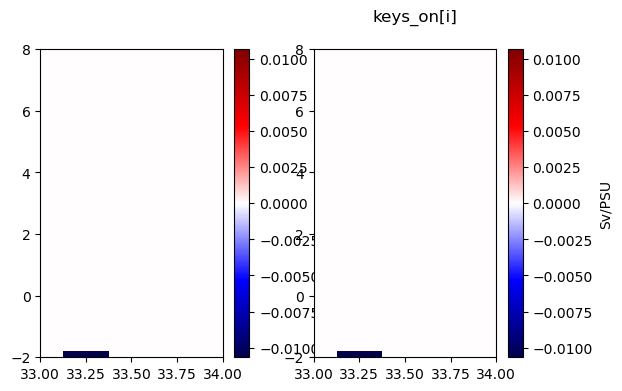

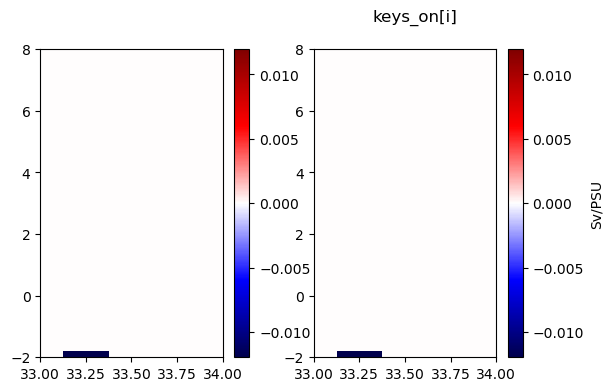

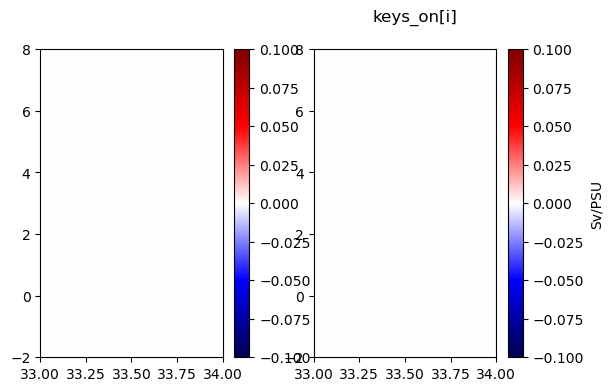

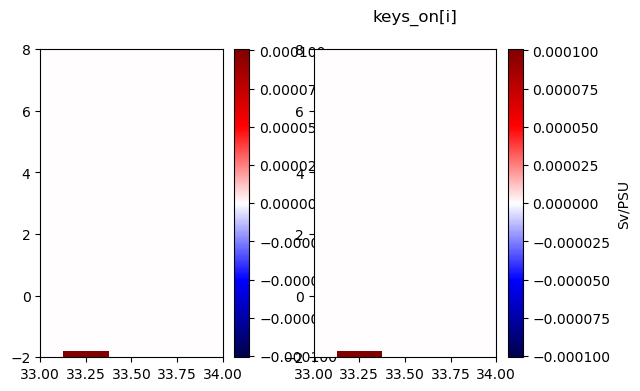

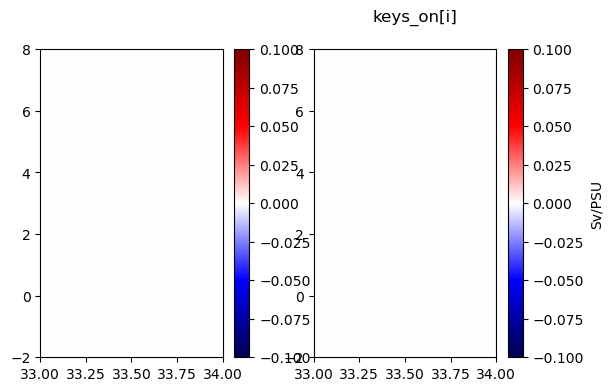

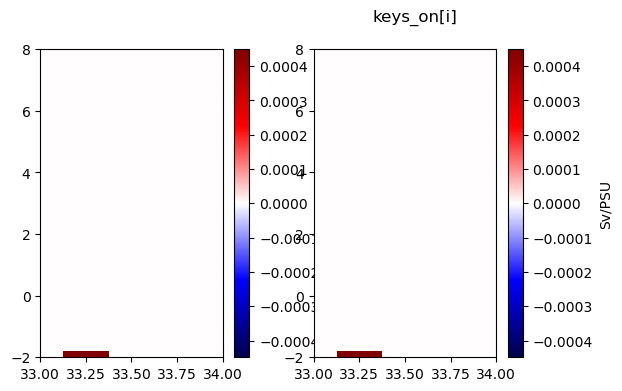

In [129]:
# plot these and the difference between them in TS space

# loop through and plot these, make sure we have the same order

order_on = np.array([0,2,1,4,3,5])
order_off = np.array([-1,0,1,2,3,4])

keys_on = list(Jy[nbasin][t].keys())[1:]
keys_off = list(termsT_TS.keys())

for i,j in zip(order_on,order_off):
    fig = plt.figure()
    vlev = np.nanmax(np.abs(Jy[nbasin][t][keys_on[i]].T))

    ax = plt.subplot(131)
    cb = ax.pcolormesh(Sbin2,Tbin2,Jy[nbasin][t][keys_on[i]].T,cmap='seismic',vmin=-vlev,vmax=vlev)
    plt.colorbar(cb,label="Sv/PSU")
    ax.set_xlim(33,34)
    ax.set_ylim(-2,8)

    ax = plt.subplot(132)
    cb = ax.pcolormesh(Sbin2,Tbin2,Jy[nbasin][t][keys_on[i]].T,cmap='seismic',vmin=-vlev,vmax=vlev)
    plt.colorbar(cb,label="Sv/PSU")
    ax.set_xlim(33,34)
    ax.set_ylim(-2,8)


    plt.suptitle("keys_on[i]")


## Grab the M term for this individual box

In [134]:
# get the G terms (the ones we need in degC.m^3/s and PSU.m^3/s on the map
# there are only TWO gates for this column -- at the North and West
# both of the two gates have two faces for items entering the bin

file_name = "budg3d_hflux_set2"
meta_budg3d_hflux_set2 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg3d_hflux_set2["fldList"])
varnames = np.array(["ADVx_TH","ADVy_TH","ADVx_SLT","ADVy_SLT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
ADVx_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
ADVy_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])
ADVx_SLT,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[2])
ADVy_SLT,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[3])

ADVx_TH = ADVx_TH.reshape((nz,ny,nx))
ADVy_TH = ADVy_TH.reshape((nz,ny,nx))
ADVx_SLT = ADVx_SLT.reshape((nz,ny,nx))
ADVy_SLT = ADVy_SLT.reshape((nz,ny,nx))

In [147]:
# print the values at the two gates which exist and we care about here
# WEST (ix) and NORTH (iy+1)
print("West gates indexed at iT = 1 and iS = 83 (top) and iS = 84 (bottom)")
print(ADVx_TH[:2,iy,ix],"degC.m^3/s")
print(ADVx_SLT[:2,iy,ix],"PSU.m^3/s")

print()

print("North gates indexed at iT = 1 and iS = 83 (top) and iS = 84 (bottom)")
print(-ADVy_TH[:2,iy+1,ix],"degC.m^3/s")
print(-ADVy_SLT[:2,iy+1,ix],"PSU.m^3/s")

print()
# these are the same values as above but binned to different T and s.
# do a check for the gates
print(np.nansum(-ADVy_TH[:2,iy+1,ix] + ADVx_TH[:2,iy,ix]))
print(np.nansum(-ADVy_SLT[:2,iy+1,ix] + ADVx_SLT[:2,iy,ix]))

# and these are the same as the values we got in the previous slide (right that makes sense)

West gates indexed at iT = 1 and iS = 83 (top) and iS = 84 (bottom)
[10314.03395862  7891.84578452] degC.m^3/s
[-188480.39923605 -145174.66448811] PSU.m^3/s

North gates indexed at iT = 1 and iS = 83 (top) and iS = 84 (bottom)
[-12731.46343656  -6669.53488955] degC.m^3/s
[232500.18231723 121982.51757945] PSU.m^3/s

-1195.1185829688702
20827.636172519793


In [149]:
# print the contribution overall in degC.m^3/s from dF_T and dF_S
print(termsT_TS['ADVh'].sum() * .25*.4)  # return to degC.m^3/s
print(termsS_TS['ADVh'].sum() * .25*.4)  # return to degC.m^3/s


-1195.118476116952
20827.63431038418


In [154]:
iS = 84
iT = 1
# cell centered values -- hard coding for now

In [175]:
# get Mx and My as terms in the TS diagram
nTm1,nSm1 = nT-1,nS-1
print(nTm1)
M_T = np.zeros((2,nTm1))  # for West, North
M_T[0,iT] += np.nansum(ADVx_TH[:2,iy,ix])
M_T[1,iT] += np.nansum(-ADVy_TH[:2,iy+1,ix])  # north gate

M_S = np.zeros((2,nTm1)) # for West, North
M_S[0,iS] += np.nansum(ADVx_SLT[1,iy,ix])
M_S[1,iS] += np.nansum(-ADVy_SLT[1,iy+1,ix])

M_S[0,iS-1] += np.nansum(ADVx_SLT[0,iy,ix])
M_S[1,iS-1] += np.nansum(-ADVy_SLT[0,iy+1,ix])

111


In [176]:
# for this column, we only have three nonzero terms to take the divergence: ADVh, DFh and surf and total tend

Text(0.5, 0, 'S')

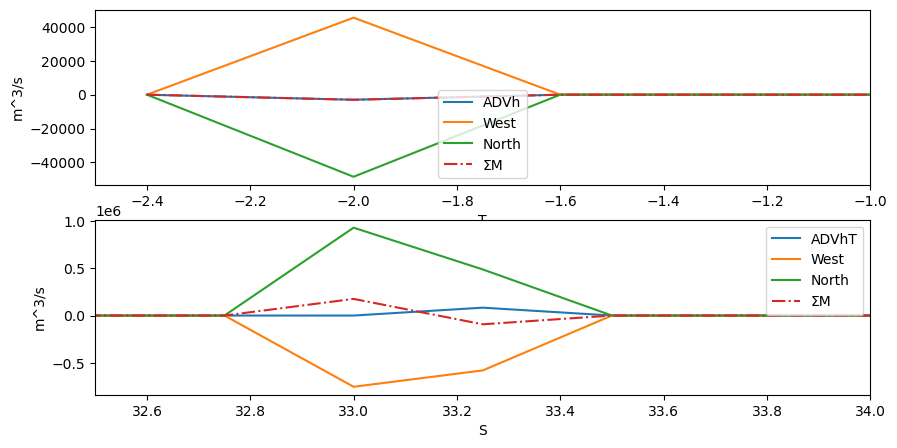

In [192]:
# plot these four TS diagrams here with the ADVh term for salt and for temp

fig = plt.figure(figsize = (10,5))

ax = plt.subplot(211)
x = boundsT.flatten()[1:-1]
ax.plot(boundsT.flatten()[1:-1],dF_Tnew[0]/binwidthT1,label="ADVh")
ax.plot(x,M_T[0]/binwidthT1,label="West")
ax.plot(x,M_T[1]/binwidthT1,label="North")
ax.plot(x,(M_T[0]+M_T[1])/binwidthT1,label="ΣM",linestyle= "-.")
ax.set_ylabel("m^3/s")
ax.legend(loc="best")
ax.set_xlim(-2.5,-1)
ax.set_xlabel("T")


ax = plt.subplot(212)
x = boundsS.flatten()[1:-1]
ax.plot(boundsS.flatten()[1:-1],dF_Snew[0]/binwidthS1,label="ADVhT")
ax.plot(x,M_S[0]/binwidthS1,label="West")
ax.plot(x,M_S[1]/binwidthS1,label="North")
ax.plot(x,(M_S[0]+M_S[1])/binwidthS1,label="ΣM",linestyle= "-.")
ax.set_ylabel("m^3/s")
ax.legend(loc="best")
ax.set_xlim(32.5,34)
ax.set_xlabel("S")

In [187]:
print(np.nansum((M_T[0]+M_T[1])/binwidthT1 - dF_Tnew[0]/binwidthT1))  # resid for temperature

print()

print(np.nansum((M_S[0]+M_S[1])/binwidthS1 - dF_Snew[0]/binwidthS1)) # resid contribution in salt
print(((M_S[0]+M_S[1])/binwidthS1 - dF_Snew[0]/binwidthS1)[83:85])

2.2737367544323206e-12

0.0
[ 176079.13232475 -176079.13232475]


In [198]:
# now make these into TS diagrams, then we can do divergence

M_T = np.zeros((nTm1,nSm1))
M_S = np.zeros((nTm1,nSm1))

# y term
M_T[1,83] += ADVx_TH[0,iy,ix]
M_T[1,84] += ADVx_TH[1,iy,ix]
M_T[1,83] -= ADVy_TH[0,iy+1,ix]
M_T[1,84] -= ADVy_TH[1,iy+1,ix]  # degC.m^3/s
M_T = M_T / 0.25 / 0.4 # hacky way to get /PSU
M_T *= 1e-6


# x term
M_S[1,83] += ADVx_SLT[0,iy,ix]
M_S[1,84] += ADVx_SLT[1,iy,ix]
M_S[1,83] -= ADVy_SLT[0,iy+1,ix]
M_S[1,84] -= ADVy_SLT[1,iy+1,ix]  # PSU.m^3/s

M_S = M_S / 0.25 / 0.4 # hacky way to get /degC
M_S *= 1e-6


Text(0.5, 1.0, 'offlinf M_T')

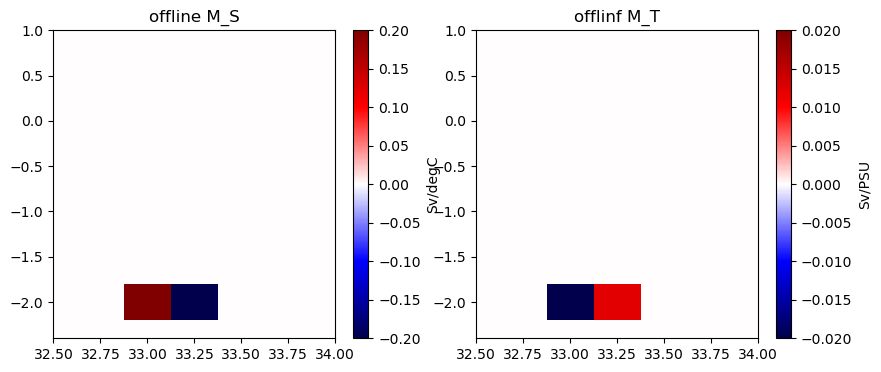

In [227]:
# take these and normalize by binwidthT1 or binwidthS1
fig = plt.figure()

ax = plt.subplot(121)
cb = ax.pcolormesh(Sbin2,Tbin2,M_S.T,cmap="seismic",vmin=-.2,vmax=.2)
plt.colorbar(cb, label="Sv/degC")
ax.set_xlim(32.5,34)
ax.set_ylim(-2.4,1)
ax.set_title("offline M_S")

ax = plt.subplot(122)
cb = ax.pcolormesh(Sbin2,Tbin2,M_T.T,cmap="seismic",vmin=-.02,vmax=.02)
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(32.5,34)
ax.set_ylim(-2.4,1)
ax.set_title("offlinf M_T")

In [200]:
# advh is the same, advr is the same, dfh is the same, dfr is the smae, surf is the same
# total tend is not the same.

# can we do convergence now with total tend and the gates

In [207]:
import numpy as np

def ts_divergence(Jy_Sv_per_PSU, Jx_Sv_per_degC, binmidT, binmidS,
                  binwidthT1=None, binwidthS1=None):
    """
    Divergence in (T,S) space from fluxes at TS cell centers.

    Inputs
    ------
    Jy_Sv_per_PSU : (nT, nS) or (nT-1, nS-1)
        "T-direction" flux (your Jy), units Sv/PSU.
        This behaves like F_T in the T-direction: divergence contribution is ∂Jy/∂T.

    Jx_Sv_per_degC : (nT, nS) or (nT-1, nS-1)
        "S-direction" flux (your Jx), units Sv/degC.
        This behaves like F_S in the S-direction: divergence contribution is ∂Jx/∂S.

    binmidT : (nT,) array
        Cell-center T coordinates (degC).
    binmidS : (nS,) array
        Cell-center S coordinates (PSU).

    binwidthT1, binwidthS1 : optional scalars or arrays
        If you want an *additional* normalization by TS-bin widths after computing
        ∂Jy/∂T + ∂Jx/∂S, pass the widths you mean here.
        - If scalar: applies everywhere.
        - If array: must be broadcastable to div shape.

    Returns
    -------
    div : array, shape (nT, nS) or (nT-1, nS-1) matching input centers
        Units: Sv/(degC*PSU) after the derivatives.
        If binwidthT1/binwidthS1 are provided, div is additionally divided by them
        (see note below).

    Notes
    -----
    ∂Jy/∂T: (Sv/PSU)/degC = Sv/(degC*PSU)
    ∂Jx/∂S: (Sv/degC)/PSU = Sv/(degC*PSU)
    so they are directly addable after differentiation.

    The optional binwidth normalization is *not* mathematically required for
    the divergence units above; use it only if your downstream convention expects it.
    """

    Jy = np.asarray(Jy_Sv_per_PSU, dtype=float)
    Jx = np.asarray(Jx_Sv_per_degC, dtype=float)

    nT = len(binmidT)
    nS = len(binmidS)

    # Accept either (nT, nS) or (nT-1, nS-1). You said 111x111, so this targets (nT, nS).
    if Jy.shape == (nT, nS) and Jx.shape == (nT, nS):
        T = np.asarray(binmidT, dtype=float)
        S = np.asarray(binmidS, dtype=float)
    elif Jy.shape == (nT - 1, nS - 1) and Jx.shape == (nT - 1, nS - 1):
        # then binmidT/binmidS must correspond to those centers
        T = np.asarray(binmidT[:-1], dtype=float)
        S = np.asarray(binmidS[:-1], dtype=float)
        nT, nS = len(T), len(S)
    else:
        raise ValueError(
            f"Shape mismatch: expected (nT,nS)=({len(binmidT)},{len(binmidS)}) "
            f"or (nT-1,nS-1)=({len(binmidT)-1},{len(binmidS)-1}); "
            f"got Jy {Jy.shape}, Jx {Jx.shape}"
        )

    # Allocate derivatives
    dJy_dT = np.empty_like(Jy)
    dJx_dS = np.empty_like(Jx)

    # --- ∂Jy/∂T along axis 0 (T dimension) ---
    # centered interior
    dT_center = (T[2:] - T[:-2])[:, None]
    dJy_dT[1:-1, :] = (Jy[2:, :] - Jy[:-2, :]) / dT_center
    # one-sided boundaries
    dJy_dT[0,  :] = (Jy[1,  :] - Jy[0,  :]) / (T[1] - T[0])
    dJy_dT[-1, :] = (Jy[-1, :] - Jy[-2, :]) / (T[-1] - T[-2])

    # --- ∂Jx/∂S along axis 1 (S dimension) ---
    dS_center = (S[2:] - S[:-2])[None, :]
    dJx_dS[:, 1:-1] = (Jx[:, 2:] - Jx[:, :-2]) / dS_center
    dJx_dS[:, 0]    = (Jx[:, 1 ] - Jx[:, 0 ]) / (S[1] - S[0])
    dJx_dS[:, -1]   = (Jx[:, -1] - Jx[:, -2]) / (S[-1] - S[-2])

    # Divergence (units Sv/(degC*PSU))
    div = dJy_dT + dJx_dS

    # Optional extra normalization by TS-bin widths (only if your convention wants it)
    if binwidthT1 is not None:
        div = div / np.asarray(binwidthT1)
    if binwidthS1 is not None:
        div = div / np.asarray(binwidthS1)

    return div


# Your call (assuming shapes are (len(binmidT), len(binmidS)) == (111,111)):
div = ts_divergence(
    Jy[nbasin][t]["LTto_TS"],   # Sv/PSU
    Jx[nbasin][t]["LSto_TS"],   # Sv/degC
    binmidT, binmidS,
    # binwidthT1=binwidthT1,   # optionally pass if you truly want this post-normalization
    # binwidthS1=binwidthS1
)

In [215]:
# Your call (assuming shapes are (len(binmidT), len(binmidS)) == (111,111)):
div_gates = ts_divergence(
    M_T,   # Sv/PSU
    M_S,   # Sv/degC
    binmidT, binmidS,
    # binwidthT1=binwidthT1,   # optionally pass if you truly want this post-normalization
    # binwidthS1=binwidthS1
)

Text(0.5, 1.0, 'div from gates or part of eq 5')

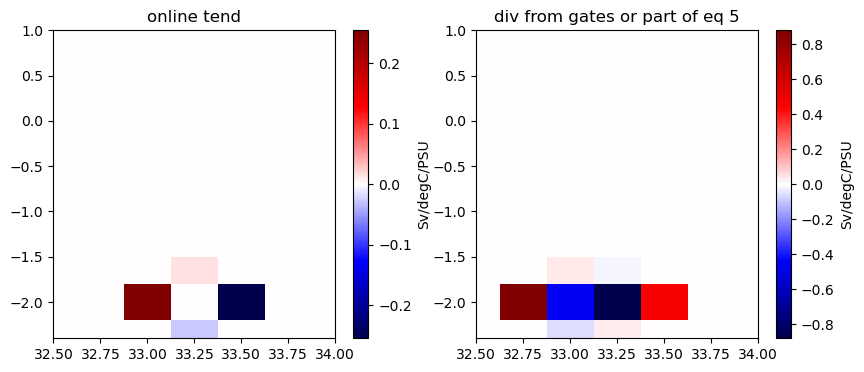

In [225]:
fig = plt.figure()

ax = plt.subplot(121)
cb = ax.pcolormesh(Sbin2,Tbin2,div.T,cmap="seismic")
plt.colorbar(cb, label="Sv/degC/PSU")
ax.set_xlim(32.5,34)
ax.set_ylim(-2.4,1)
ax.set_title("online tend")

ax = plt.subplot(122)
cb = ax.pcolormesh(Sbin2,Tbin2,div_gates.T,cmap="seismic")
plt.colorbar(cb, label="Sv/degC/PSU")
ax.set_xlim(32.5,34)
ax.set_ylim(-2.4,1)
ax.set_title("div from gates or part of eq 5")